## Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

dataset_path = Path("../dataset")
dl_data_path = dataset_path / "dl_data"

## Load the data

X_train = np.load(dl_data_path / "X_train.npy")
X_validation = np.load(dl_data_path / "X_validation.npy")
X_test = np.load(dl_data_path / "X_test.npy")

y_train = np.load(dl_data_path / "y_train.npy")
y_validation = np.load(dl_data_path / "y_validation.npy")
y_test = np.load(dl_data_path / "y_test.npy")

print("===== Datasets loaded successfully. =====")

print("\nDataset shapes:")
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_validation:", y_validation.shape)
print("y_test:", y_test.shape)

===== Datasets loaded successfully. =====

Dataset shapes:
X_train: (5969, 9000)
X_validation: (1279, 9000)
X_test: (1280, 9000)
y_train: (5969,)
y_validation: (1279,)
y_test: (1280,)


## Normalization && Preprocessing

In [2]:
## Preprocess the data

X_train = X_train.astype(np.float32)
X_validation = X_validation.astype(np.float32)
X_test = X_test.astype(np.float32)


# Normalize using training data statistics

train_mean = X_train.mean()
train_std = X_train.std()

X_train = (X_train - train_mean) / train_std
X_validation = (X_validation - train_mean) / train_std
X_test = (X_test - train_mean) / train_std


print("\n===== NORMALIZATION CHECK =====")

print("Train:")
print("Mean:", X_train.mean())
print("Std:", X_train.std())

print("\nValidation:")
print("Mean:", X_validation.mean())
print("Std:", X_validation.std())

print("\nTest:")
print("Mean:", X_test.mean())
print("Std:", X_test.std())


===== NORMALIZATION CHECK =====
Train:
Mean: 8.628554e-08
Std: 1.0000006

Validation:
Mean: 0.00015843338
Std: 1.0341631

Test:
Mean: 0.0026376029
Std: 1.0162377


## Channel Dimension

In [3]:
## Reshape the data to add a channel dimension

X_train = X_train[..., np.newaxis]
X_validation = X_validation[..., np.newaxis]
X_test = X_test[..., np.newaxis]


print("\n===== RESNET INPUT SHAPES =====")

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)


===== RESNET INPUT SHAPES =====
X_train: (5969, 9000, 1)
X_validation: (1279, 9000, 1)
X_test: (1280, 9000, 1)


## Import TensorFlow

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


## Residual Block

In [5]:
def residual_block(x, filters, kernel_size=3, stride=1):

    # Shortcut connection
    shortcut = x

    # First convolution
    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        strides=stride,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Second convolution
    x = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        strides=1,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)

    # Match shortcut dimensions if necessary
    if shortcut.shape[-1] != filters or stride != 1:

        shortcut = layers.Conv1D(
            filters=filters,
            kernel_size=1,
            strides=stride,
            padding="same",
            use_bias=False
        )(shortcut)

        shortcut = layers.BatchNormalization()(shortcut)

    # Residual connection
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

## Create 1D ResNet

In [6]:
## Build 1D ResNet

inputs = layers.Input(shape=(9000, 1))


# Initial convolution

x = layers.Conv1D(
    filters=32,
    kernel_size=7,
    strides=2,
    padding="same",
    use_bias=False
)(inputs)

x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = layers.MaxPooling1D(
    pool_size=3,
    strides=2,
    padding="same"
)(x)


# Residual Stage 1

x = residual_block(
    x,
    filters=32
)

x = residual_block(
    x,
    filters=32
)


# Residual Stage 2

x = residual_block(
    x,
    filters=64,
    stride=2
)

x = residual_block(
    x,
    filters=64
)


# Residual Stage 3

x = residual_block(
    x,
    filters=128,
    stride=2
)

x = residual_block(
    x,
    filters=128
)


# Global feature extraction

x = layers.GlobalAveragePooling1D()(x)


# Fully connected layer

x = layers.Dense(
    64,
    activation="relu"
)(x)


# Output layer

outputs = layers.Dense(
    4,
    activation="softmax"
)(x)


model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="ECG_1D_ResNet_Weighted"
)


model.summary()

Model: "ECG_1D_ResNet_Weighted"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 9000, 1)]    0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 4500, 32)     224         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 4500, 32)    128         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 re_lu (ReLU)                   (None, 4500, 32)     0           ['batch_norm

## Compile Model

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Class Weights

In [8]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(
    zip(classes, class_weights)
)


print("===== RESNET CLASS WEIGHTS =====")

for class_id, weight in class_weight_dict.items():
    print(f"Class {class_id}: {weight:.4f}")

===== RESNET CLASS WEIGHTS =====
Class 0: 0.4200
Class 1: 2.8103
Class 2: 0.8830
Class 3: 7.6526


## Callbacks

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)


model_checkpoint = ModelCheckpoint(
    "best_1d_resnet_weighted.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

## Training

In [10]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_validation,
        y_validation
    ),

    epochs=50,
    batch_size=32,

    class_weight=class_weight_dict,

    callbacks=[
        early_stopping,
        model_checkpoint
    ],

    verbose=1
)

Epoch 1/50
187/187 [==============================] - ETA: 0s - loss: 1.1235 - accuracy: 0.3905
Epoch 1: val_loss improved from inf to 0.96084, saving model to best_1d_resnet_weighted.keras
187/187 [==============================] - 39s 125ms/step - loss: 1.1235 - accuracy: 0.3905 - val_loss: 0.9608 - val_accuracy: 0.5981
Epoch 2/50
187/187 [==============================] - ETA: 0s - loss: 0.9527 - accuracy: 0.4813
Epoch 2: val_loss did not improve from 0.96084
187/187 [==============================] - 20s 105ms/step - loss: 0.9527 - accuracy: 0.4813 - val_loss: 1.1521 - val_accuracy: 0.3346
Epoch 3/50
187/187 [==============================] - ETA: 0s - loss: 0.8363 - accuracy: 0.5492
Epoch 3: val_loss did not improve from 0.96084
187/187 [==============================] - 20s 106ms/step - loss: 0.8363 - accuracy: 0.5492 - val_loss: 1.4042 - val_accuracy: 0.4300
Epoch 4/50
187/187 [==============================] - ETA: 0s - loss: 0.7969 - accuracy: 0.5678
Epoch 4: val_loss did not 

## Test Evaluation

In [11]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("===== 1D RESNET WEIGHTED TEST RESULTS =====")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

40/40 [==============================] - 2s 32ms/step - loss: 0.7796 - accuracy: 0.6727
===== 1D RESNET WEIGHTED TEST RESULTS =====
Test Loss: 0.7796
Test Accuracy: 0.6727


## Prediction && Confusion Matrix

In [12]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


y_pred_prob = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)


cm = confusion_matrix(
    y_test,
    y_pred
)


print("===== WEIGHTED CONFUSION MATRIX =====")
print(cm)

40/40 [==============================] - 2s 34ms/step
===== WEIGHTED CONFUSION MATRIX =====
[[689   1  39  33]
 [ 22  15  67   9]
 [205  12 122  24]
 [  7   0   0  35]]


## Graphic Confusion Matrix

<Figure size 700x600 with 0 Axes>

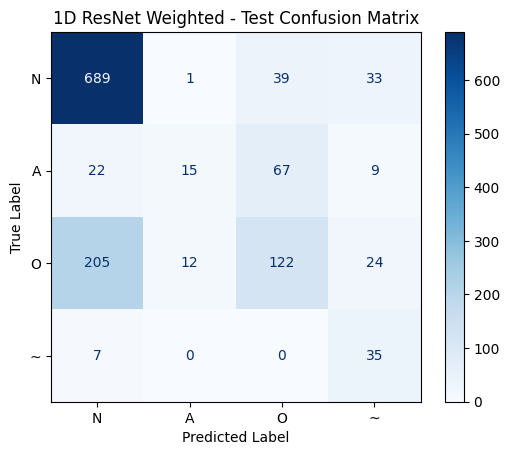

In [13]:
class_names = ["N", "A", "O", "~"]


plt.figure(figsize=(7, 6))


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)


disp.plot(
    cmap="Blues",
    values_format="d"
)


plt.title(
    "1D ResNet Weighted - Test Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Classification Report

In [14]:
print("===== WEIGHTED CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

===== WEIGHTED CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           N     0.7465    0.9042    0.8178       762
           A     0.5357    0.1327    0.2128       113
           O     0.5351    0.3361    0.4129       363
           ~     0.3465    0.8333    0.4895        42

    accuracy                         0.6727      1280
   macro avg     0.5410    0.5516    0.4832      1280
weighted avg     0.6548    0.6727    0.6388      1280



## Training / Validation Loss

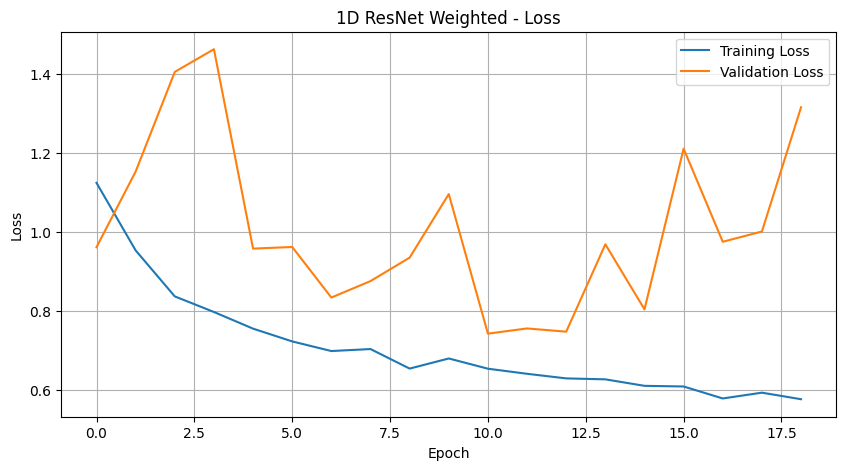

In [15]:
plt.figure(figsize=(10, 5))


plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.title(
    "1D ResNet Weighted - Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

## Training / Validation Accuracy

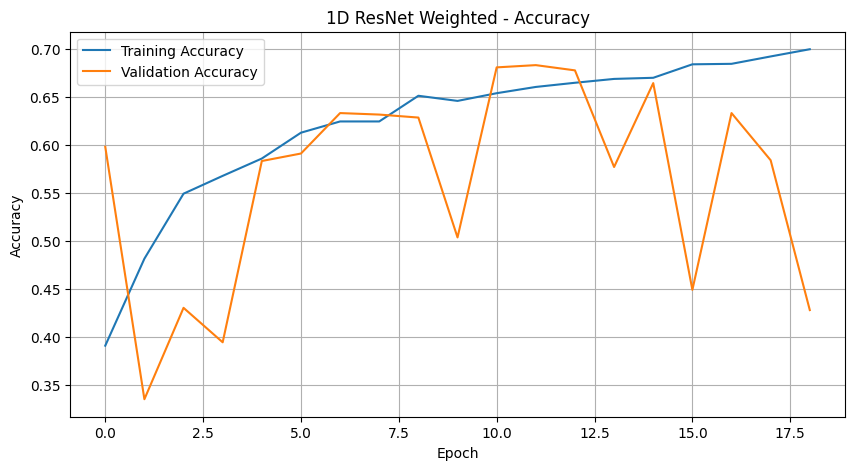

In [16]:
plt.figure(figsize=(10, 5))


plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)


plt.title(
    "1D ResNet Weighted - Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()